# Analyse multidimensionnelle des trajectoires de soins pour le jeu de données Synthea

Ce notebook présente l'application du package `trajectoryclusteringanalysis` sur un jeu de données de prescriptions de médicaments exprimé en jours.

1. Configuration de l'environnement et imports
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Décomposition par l'algorithme SWoTTeD
5. Clustering sur les intensités des phénotypes

Les données utilisées ont été générées par Synthea. 
> Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. *Synthea™ Novel coronavirus (COVID-19) model and synthetic data set*. Intelligence-Based Medicine. 2020 Nov;1:100007. [https://doi.org/10.1016/j.ibmed.2020.100007](https://doi.org/10.1016/j.ibmed.2020.100007)

## 1. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import random
import matplotlib.patches as mpatches

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


## 2. Chargement et préparation des données

In [2]:
df_synthea = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")
df_synthea['time'] = df_synthea['time'].clip(upper=30)

# Dictionnaire pour simplifier les noms des médicaments
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df_synthea['medication_events'] = df_synthea['medication_events'].map(medication_mapping)


print(f"Nombre de patients : {df_synthea['patient_id'].nunique()}")
print(f"Temps de suivi max (jours) : {df_synthea['time'].max()}")
df_synthea.head()

Nombre de patients : 901
Temps de suivi max (jours) : 30


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,22,Fluticasone Inhaler
3,1,22,Albuterol Inhaler
4,1,30,Fluticasone Inhaler


## 3. Initialisation du modèle TCA

In [3]:
label_encoder = LabelEncoder()
timed_event_structure = df_synthea.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_

tca = TCA(data=timed_event_structure,
          index_col='ID_PATIENT',
          time_col='Time', 
          event_col='Event',
          mode='multidimensional'
         )

tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9
Tensor shape: torch.Size([901, 10, 31])


On peut visualiser la trajectoires de soins d'un des patients du tenseur.

Patient utilisé pour la visualisation: 548


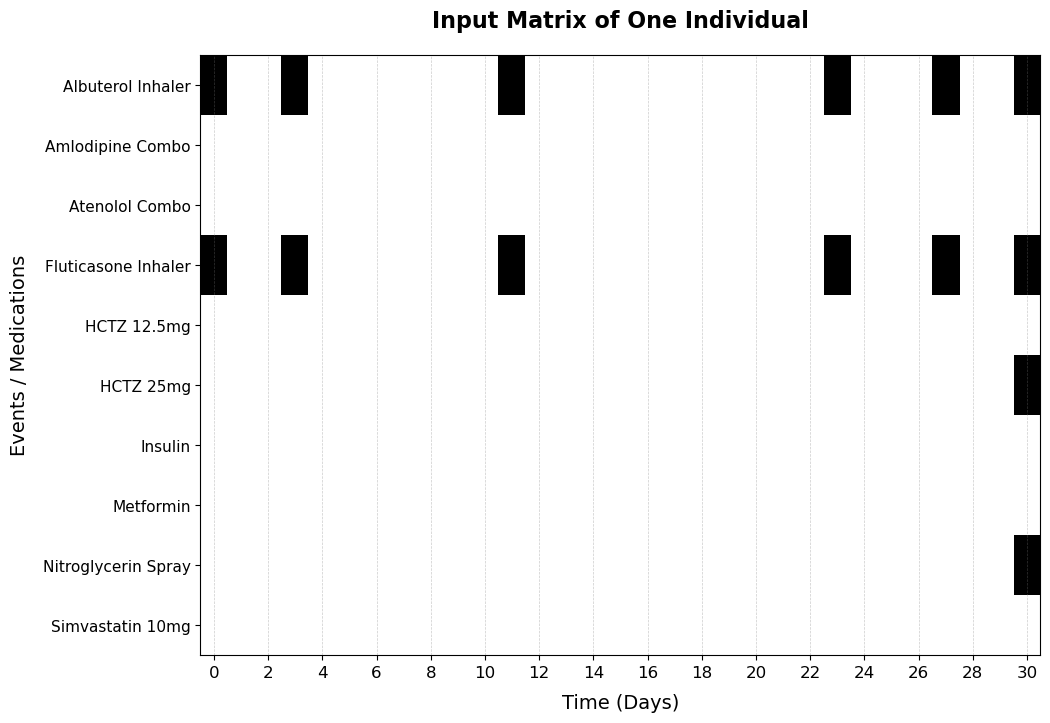

In [4]:
# Un patient avec au moins 3/4 traitements diff.
patients_complexes = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: len(set(group['Event'])) >= 4
)['ID_PATIENT'].unique()

patient_index = int(patients_complexes[0])
print(f"Patient utilisé pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit="Days")

## 4. Décomposition du jeu de données à l'aide de l'algorithme SWOTTED

On souhaite décomposer le jeu de données en plusieurs phénotypes, on peut faire varier la durée de ces phénotypes ainsi que leurs nombres afin de faire un clustering par la suite.

In [8]:
# Hyperparametres de la demo
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 200  # 30 pour demo rapide, 100+ pour entrainement plus stable

In [ ]:
ranks = [2, 3, 4]
windows = [2, 3, 4]
#sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
sparsities = [0.5, 0.7, 0.9]
non_successions = [0.1, 0.3, 0.5, 0.7, 0.9]
models = {}

# Nombre max de tests
n_essais_max = 10


for i in range(n_essais_max):
    r = random.choice(ranks)
    w = random.choice(windows)
    s = random.choice(sparsities)
    ns = random.choice(non_successions)
    
    print(f"\n--- Essai {i+1}/{n_essais_max} : R={r}, W={w}, S={s}, NS={ns} ---")
    
    tca.analyzer.fit_swotted_decomposition(
        tensor, rank=r, time_window_length=w, 
        reg_term_ns=ns, reg_term_s=s, metric=metric, 
        learning_rate=learning_rate, n_epochs=n_epochs, fit_metric_every_n_epochs=0 
    )

    models[(r, w, s, ns)] = (tca.analyzer.model, tca.analyzer.W)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 60     | n/a   | n/a  
---------------------------------------------------------------
60        Trainable params
0         Non-trainable params
60        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval


--- Essai 1/10 : R=2, W=3, S=0.9, NS=0.3 ---


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 - train_loss: 86.861389
Epoch 2/200 - train_loss: 53.365486
Epoch 3/200 - train_loss: 43.947830
Epoch 4/200 - train_loss: 45.601112
Epoch 5/200 - train_loss: 49.431610
Epoch 6/200 - train_loss: 46.361599
Epoch 7/200 - train_loss: 42.312752
Epoch 8/200 - train_loss: 57.558460
Epoch 9/200 - train_loss: 39.293503
Epoch 10/200 - train_loss: 47.070644
Epoch 11/200 - train_loss: 47.085915
Epoch 12/200 - train_loss: 45.321163
Epoch 13/200 - train_loss: 44.821964
Epoch 14/200 - train_loss: 41.097206
Epoch 15/200 - train_loss: 40.653908
Epoch 16/200 - train_loss: 44.651077
Epoch 17/200 - train_loss: 44.252052
Epoch 18/200 - train_loss: 47.192307
Epoch 19/200 - train_loss: 46.890030
Epoch 20/200 - train_loss: 46.592133
Epoch 21/200 - train_loss: 46.871529
Epoch 22/200 - train_loss: 46.268631
Epoch 23/200 - train_loss: 45.991657
Epoch 24/200 - train_loss: 46.424564
Epoch 25/200 - train_loss: 46.144028
Epoch 26/200 - train_loss: 45.438030
Epoch 27/200 - train_loss: 44.087387
Epoch 28/2

Epoch 200/300 - FIT metric: -6.7119
--- Essai 10/10 : R=4, W=10, S=0.1, NS=0.3 ---

Decomposed into 901 pathways with rank 3 and time window length 2
Success rate for the entire dataset: -1.1175


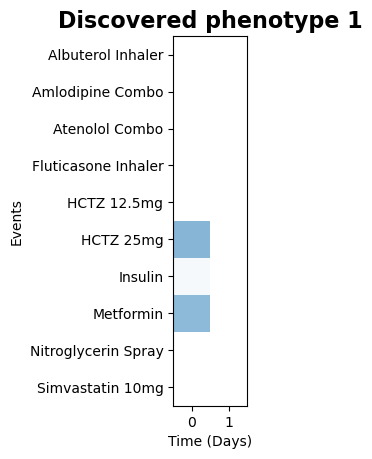

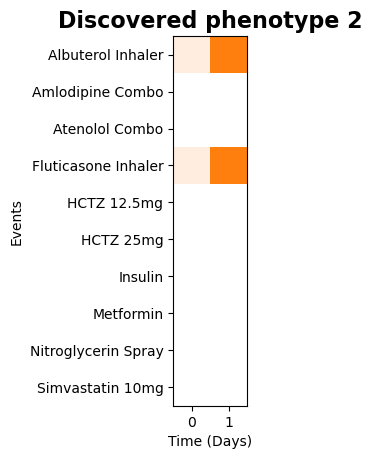

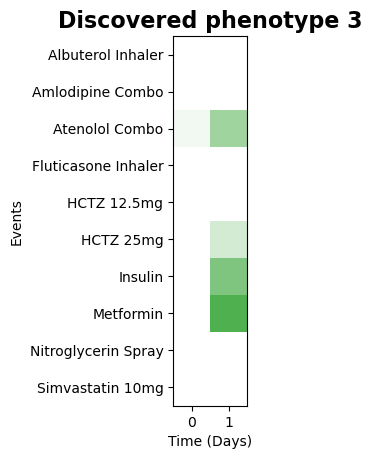

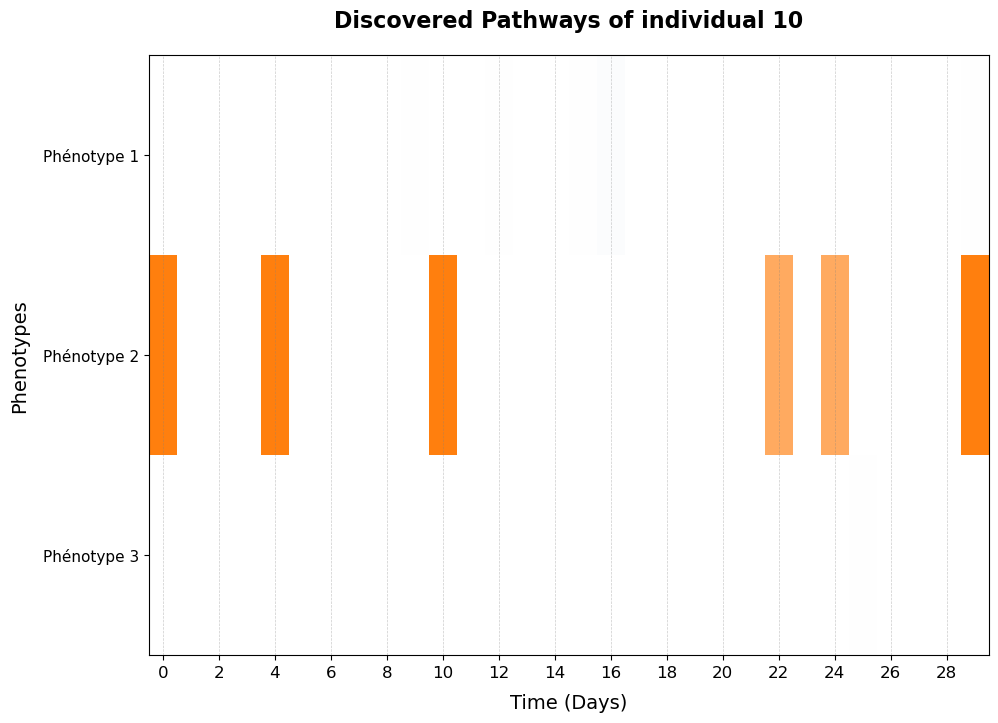

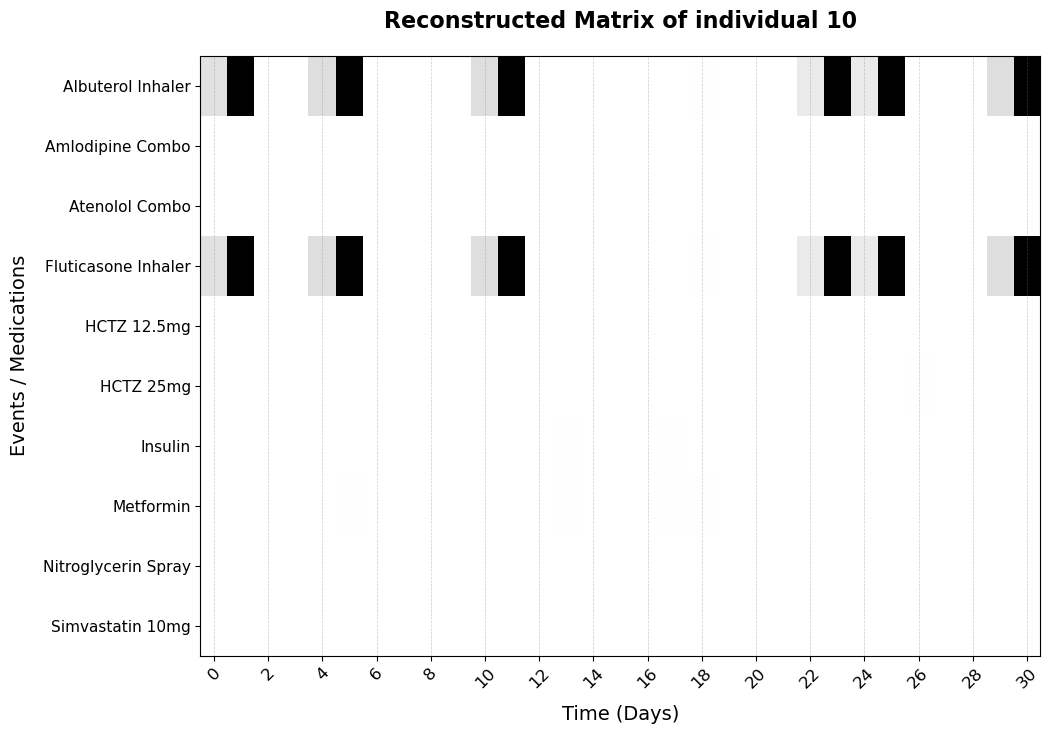

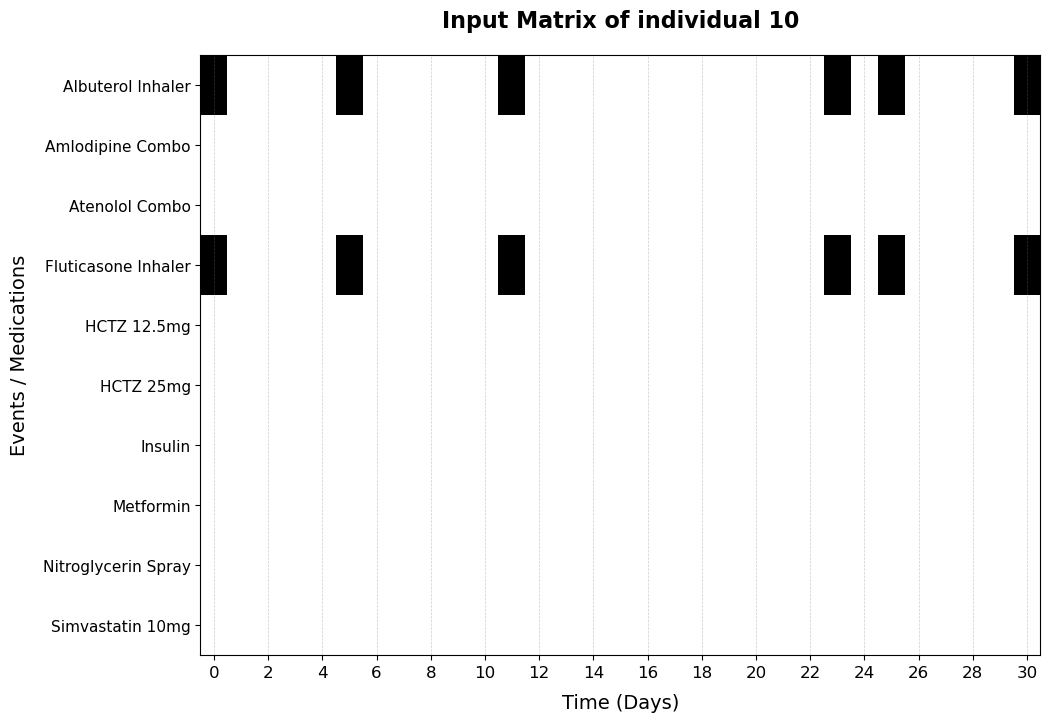

In [43]:
best_rank = 3
best_window = 2
best_reg_term_s = 0.9
best_reg_term_ns = 0.5

tca.analyzer.model, tca.analyzer.W = models[(best_rank, best_window, best_reg_term_s, best_reg_term_ns)]
tca.analyzer.get_decomposition_results(labels=noms_events, id=10, time_unit='Days')

Decomposed into 901 pathways with rank 3 and time window length 2
Success rate for the entire dataset: -1.1175


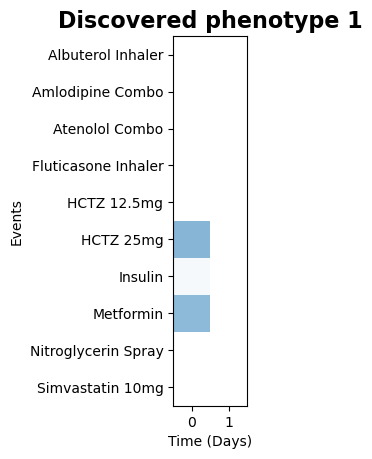

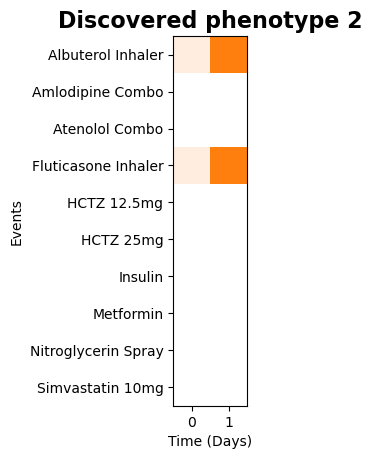

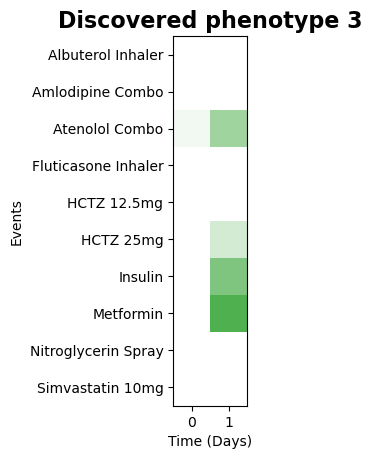

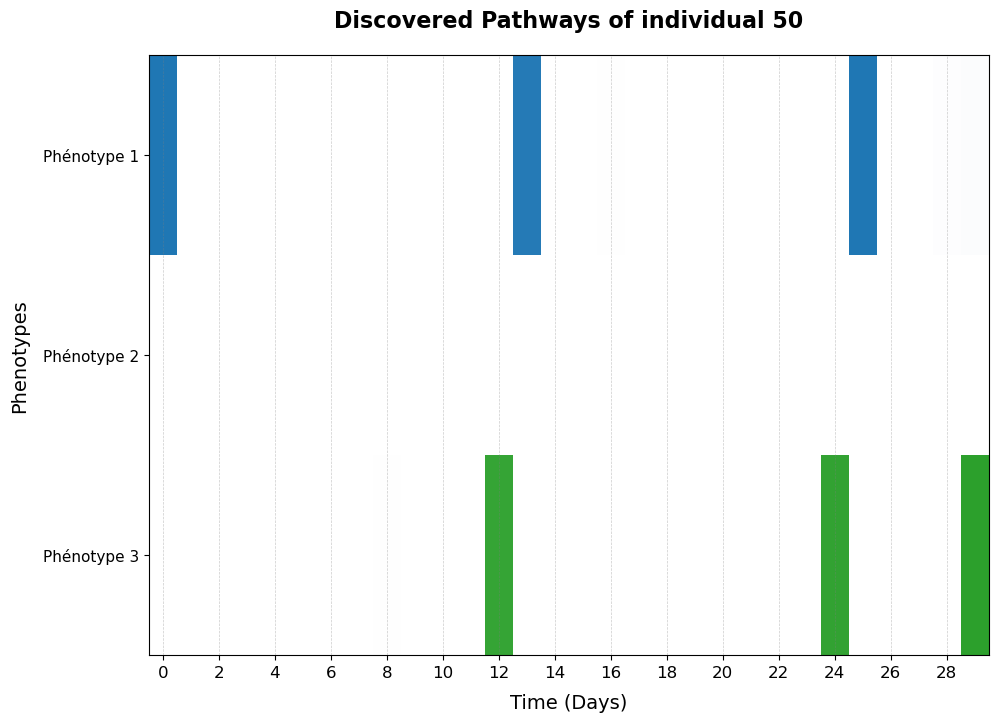

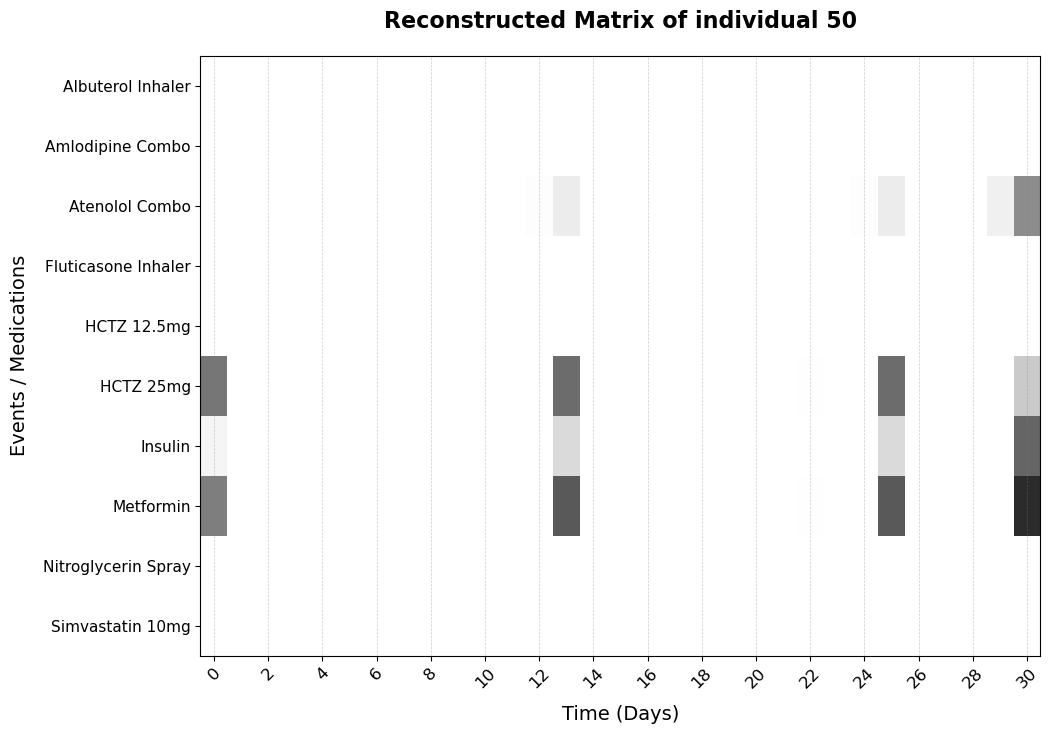

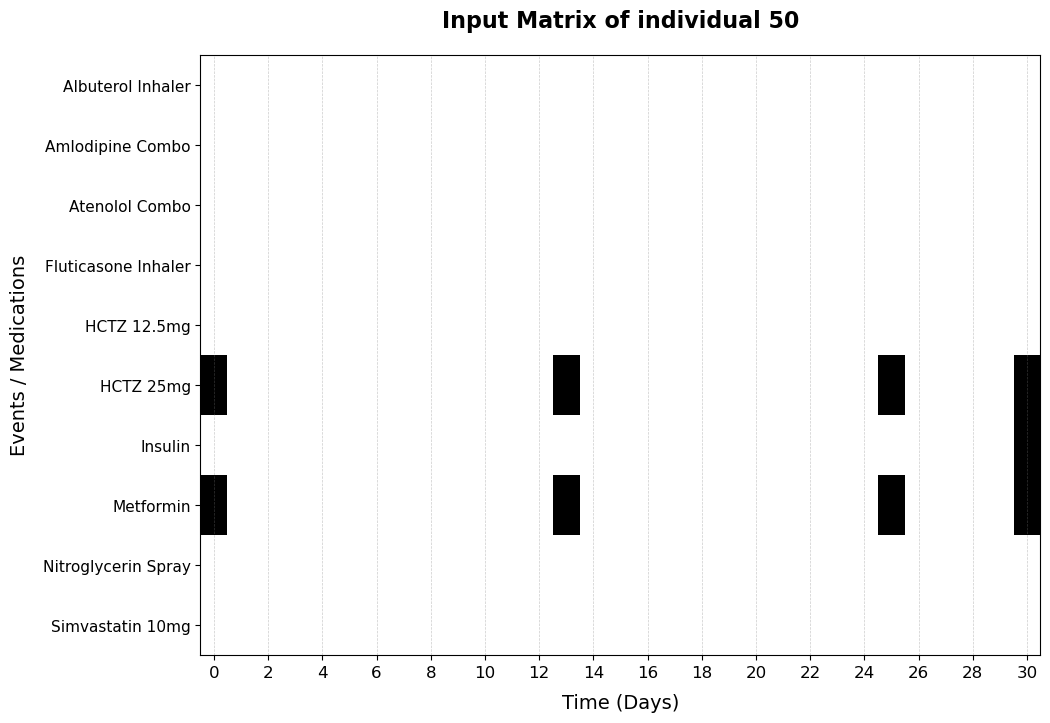

In [15]:
patient_index1 = int(patients_complexes[3])
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index1, time_unit='Days')

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [16]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (901, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.004460,0.403137,0.002004,1
1,0.003209,0.700248,0.001190,2
2,0.002801,0.000216,0.190532,3
3,0.001417,0.784381,0.002097,4
4,0.602960,0.000668,0.118094,5


### 5.2. Clustering à partir des intensités :

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


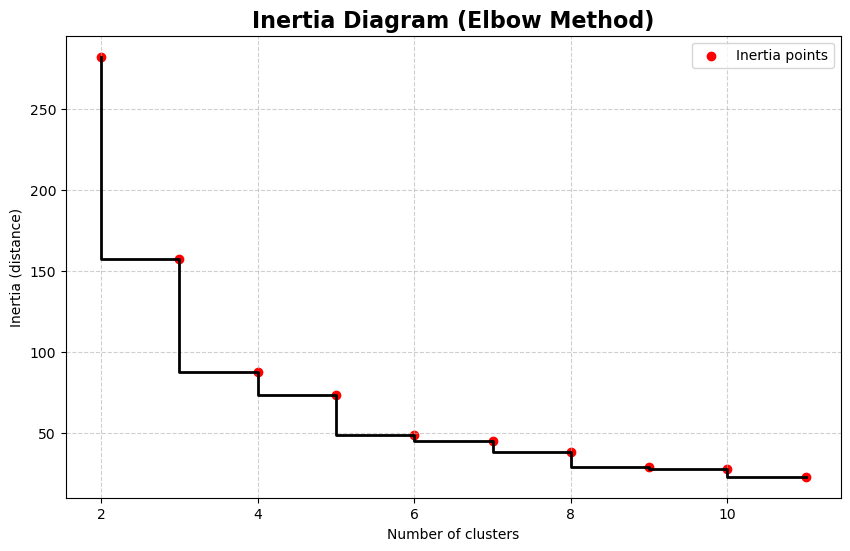

In [17]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

On choisit le nombre de clusters grâce au plot de l'inertie, ici cela semble intéressant de choisir 3 clusters.

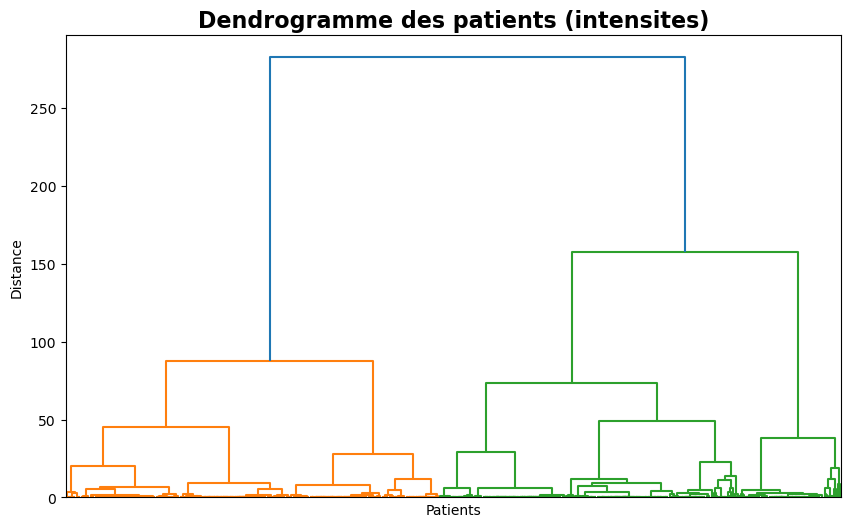

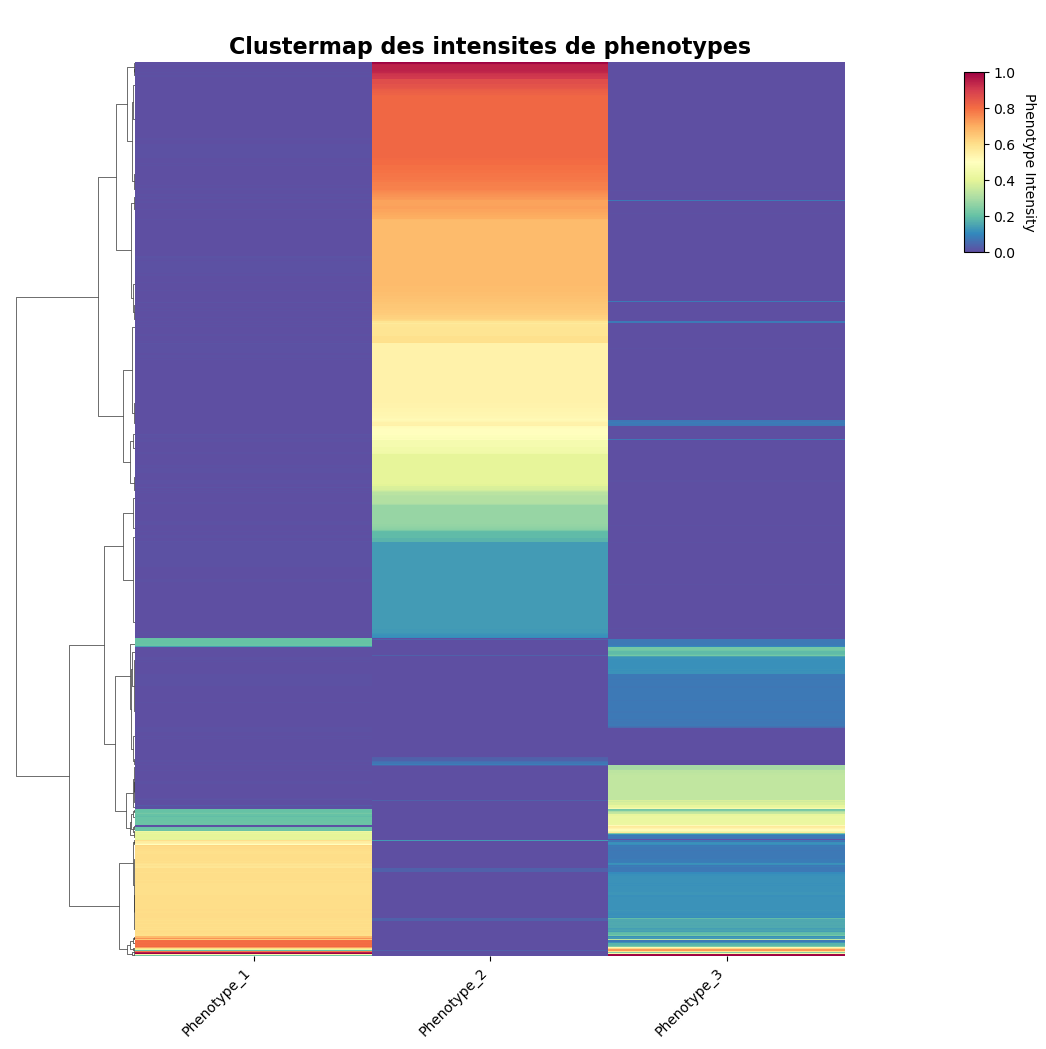

Effectifs par cluster:
1    433
2    351
3    117
Name: count, dtype: int64


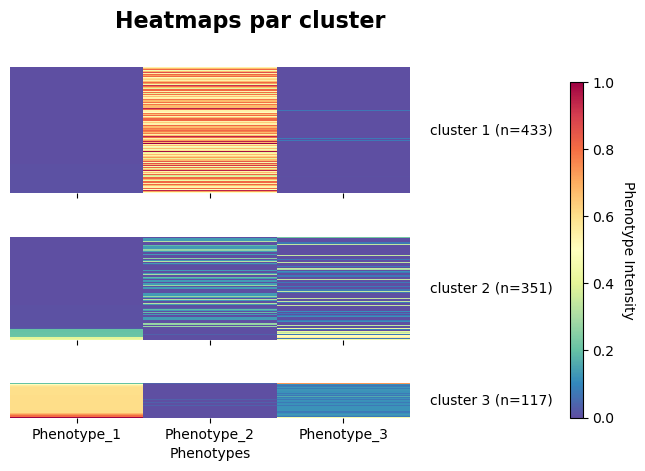

In [18]:
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=3)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

* Cluster 1 : Patients en chimiothérapie (Phénotype 2)
    - Une partie des patients de ce cluster ont une intensité proche de 1 pour le phénotype 1, et ils ont des intensités nulles pour les autres phénotypes

* Cluster 2 :
    - Pour la majorité des patients de ce cluster, on a une intensité de 0 pour le phénotype 2, et des intensités proches de 0 pour les autres phénotypes, mais le phénotype 3 domine un peu plus.

* Cluster 3 :
    - Les patients ont une intensité nulle pour le phénotype 1, et une intensité autour de 0.5 pour le phénotype 2.

Pour chaque cluster, on peut regarder le premier médicament prescrit

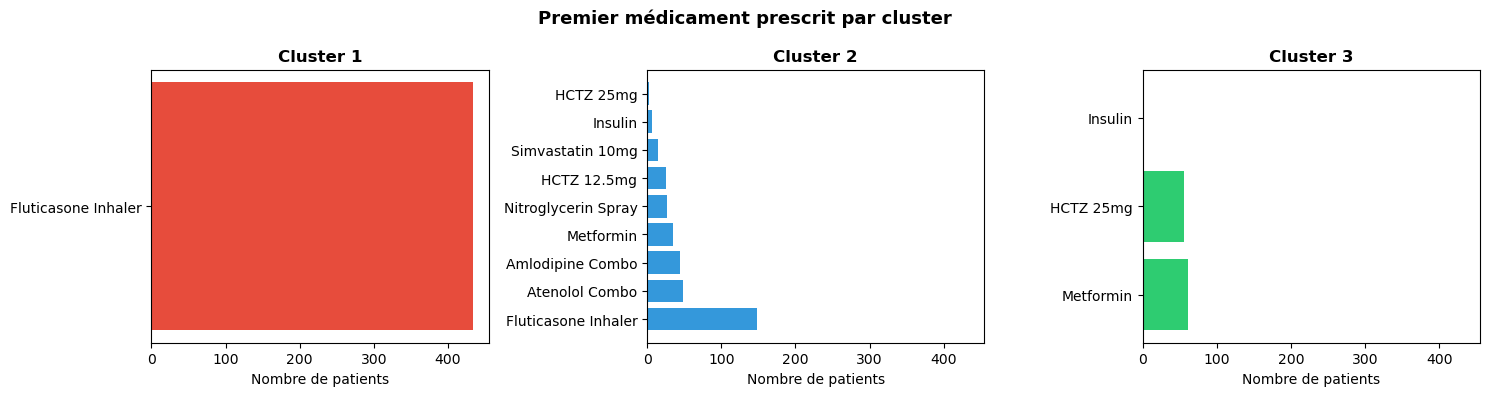

In [19]:
# Premier médicament prescrit par cluster
first_med = timed_event_structure.groupby('ID_PATIENT').apply(
    lambda x: noms_events[x.loc[x['Time'].idxmin(), 'Event']])

fig, axes = plt.subplots(1, len(set(clusters)), figsize=(5*len(set(clusters)), 4), squeeze=False, sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71']
for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    counts = first_med[ids].value_counts()
    ax.barh(counts.index, counts.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Nombre de patients")
fig.suptitle("Premier médicament prescrit par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

On peut aussi regarder la durée totale moyenne sous chaque médicament par cluster.

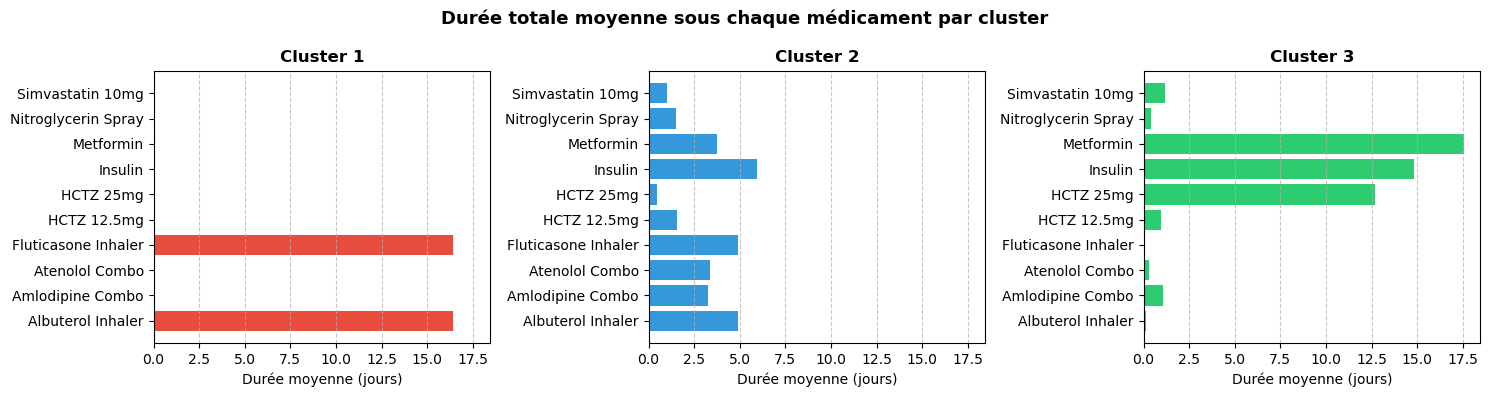

In [20]:
# Durée totale sous chaque médicament par cluster
duree_trait = timed_event_structure.copy()
duree_trait['Medicament'] = duree_trait['Event'].map(dict(enumerate(noms_events)))
duree_pivot = duree_trait.groupby(['ID_PATIENT', 'Medicament'])['Time'].count().unstack(fill_value=0)

fig, axes = plt.subplots(1, len(set(clusters)), figsize=(5*len(set(clusters)), 4), squeeze=False, sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    cluster_data = duree_pivot.loc[duree_pivot.index.isin(ids)].mean()
    ax.barh(cluster_data.index, cluster_data.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Durée moyenne (jours)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)
fig.suptitle("Durée totale moyenne sous chaque médicament par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def plot_reconstructed_vs_original(tca, patient_id, noms_events=None, figsize=(14, 8)):
    """
    Superpose la trajectoire réelle et la trajectoire reconstruite
    """
    if noms_events is None:
        noms_events = tca.analyzer.data[tca.analyzer.event_col].unique().tolist()
        
    labels = tca.analyzer.data[tca.analyzer.event_col].unique().tolist()
    
    # Extraction des matrices
    matrice_orig = tca.analyzer.get_tensor()[patient_id - 1].detach().cpu().numpy()
    matrice_recon = tca.analyzer.compute_reconstruction()[patient_id - 1].detach().cpu().numpy()

    # Affichage des résultats de la décomposition SWoTTeD
    tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_id, time_unit='Days')

    # Binarisation pour les événements réels
    orig_bin = matrice_orig > 0
    seuil = 0.2
    recon_bin = matrice_recon > seuil

    matrice_recon[matrice_recon < 0.01] = 0.0

    # Normalisation de l'intensité
    vmax = np.max(matrice_recon) if np.max(matrice_recon) > 0.1 else 1.0
    intensite = np.clip(matrice_recon / vmax, 0, 1)

    hauteur, largeur = matrice_orig.shape
    image_rgb = np.ones((hauteur, largeur, 3))

    # Cas A : SWoTTeD prédit un évènement qui n'existe pas (rouge variable selon l'intensité)
    masque_vide_original = ~orig_bin
    int_r = intensite[masque_vide_original]

    image_rgb[masque_vide_original, 0] = (1 - int_r) + 0.91 * int_r  # Canal Rouge
    image_rgb[masque_vide_original, 1] = (1 - int_r) + 0.30 * int_r  # Canal Vert
    image_rgb[masque_vide_original, 2] = (1 - int_r) + 0.24 * int_r  # Canal Bleu

    # Cas B : SWoTTeD prédit correctement un évènement réel (vert variable selon l'intensité)
    masque_orig = orig_bin
    int_g = intensite[masque_orig]

    r_pale, g_pale, b_pale = 0.66, 0.90, 0.81
    r_vif, g_vif, b_vif = 0.18, 0.80, 0.44

    image_rgb[masque_orig, 0] = r_pale * (1 - int_g) + r_vif * int_g
    image_rgb[masque_orig, 1] = g_pale * (1 - int_g) + g_vif * int_g
    image_rgb[masque_orig, 2] = b_pale * (1 - int_g) + b_vif * int_g

    # Cas C : Événements pas retrouvés (Bleu) (Uniquement si l'intensité est quasi-nulle (< 0.01))
    masque_bleu = orig_bin & (intensite < 0.01)
    image_rgb[masque_bleu] = [0.20, 0.60, 0.86]

    plt.figure(figsize=figsize)
    plt.imshow(image_rgb, aspect='auto')

    plt.yticks(ticks=np.arange(len(labels)), labels=noms_events, fontsize=10)
    plt.xticks(ticks=np.arange(0, largeur, 2), fontsize=10)
    plt.xlabel("Temps (Jours)", fontsize=12)
    plt.ylabel("Événements / Médicaments", fontsize=12)
    plt.title(f"Trajectoire réelle VS trajectoire reconstruite du Patient {patient_id}", pad=20, fontweight='bold', fontsize=14)

    legend_patches = [
        mpatches.Patch(color='#e74c3c', alpha=0.5, label='Faux positifs de SWoTTeD'),
        mpatches.Patch(color='#3498db', label='Faux négatifs de SWoTTeD'),
        mpatches.Patch(color='#2ecc71', label='Bonne reconstruction')
    ]
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

    plt.tight_layout()
    plt.show()

Decomposed into 901 pathways with rank 3 and time window length 2
Success rate for the entire dataset: -1.1175


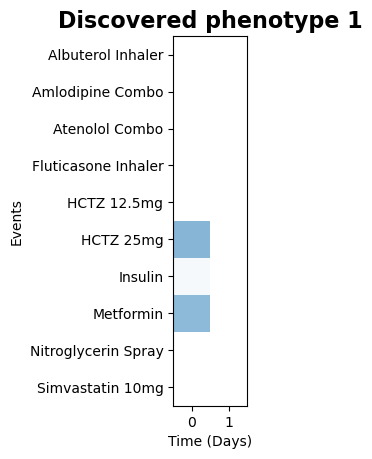

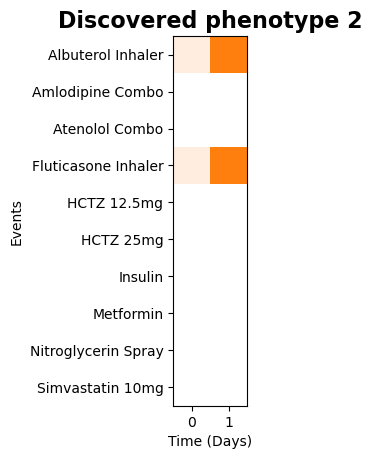

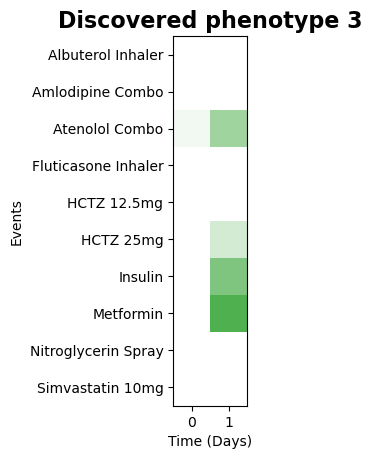

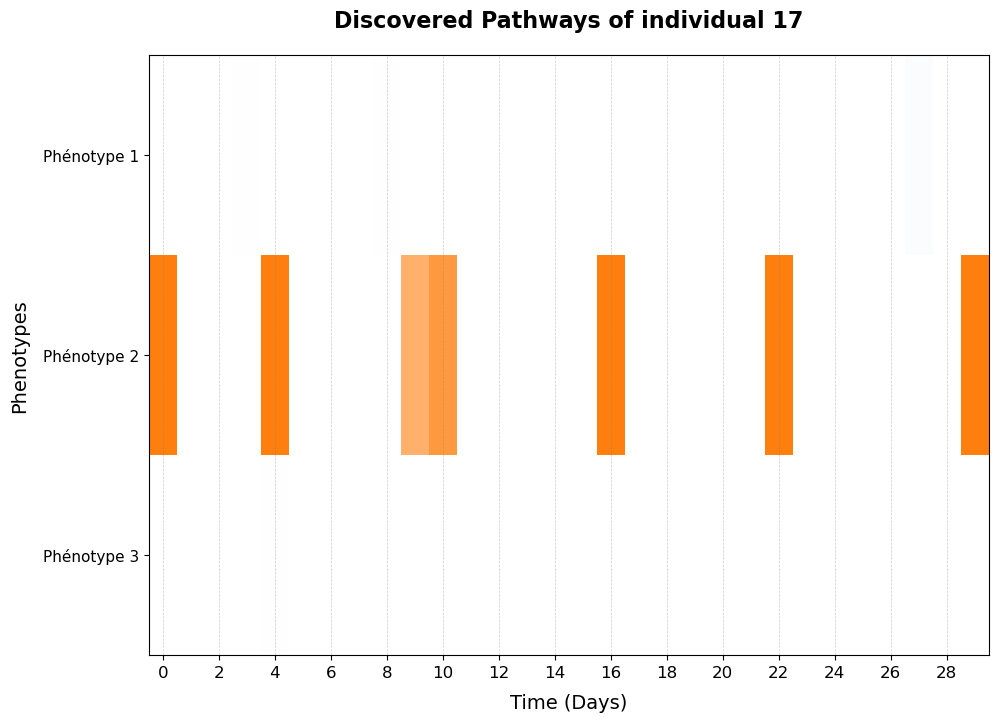

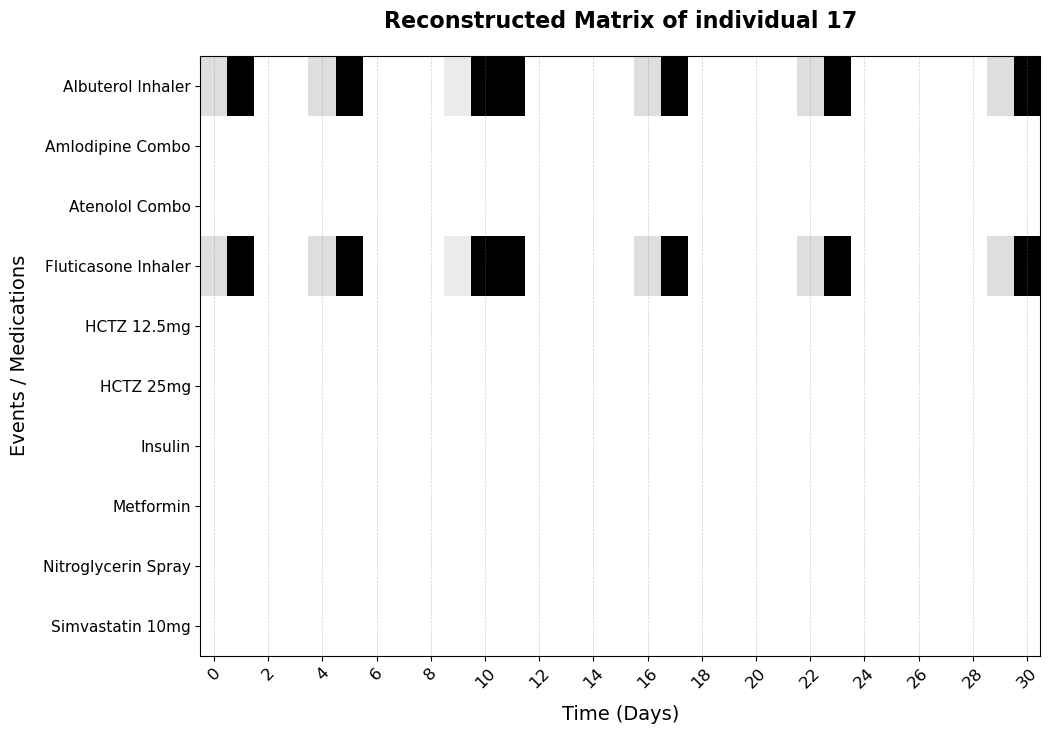

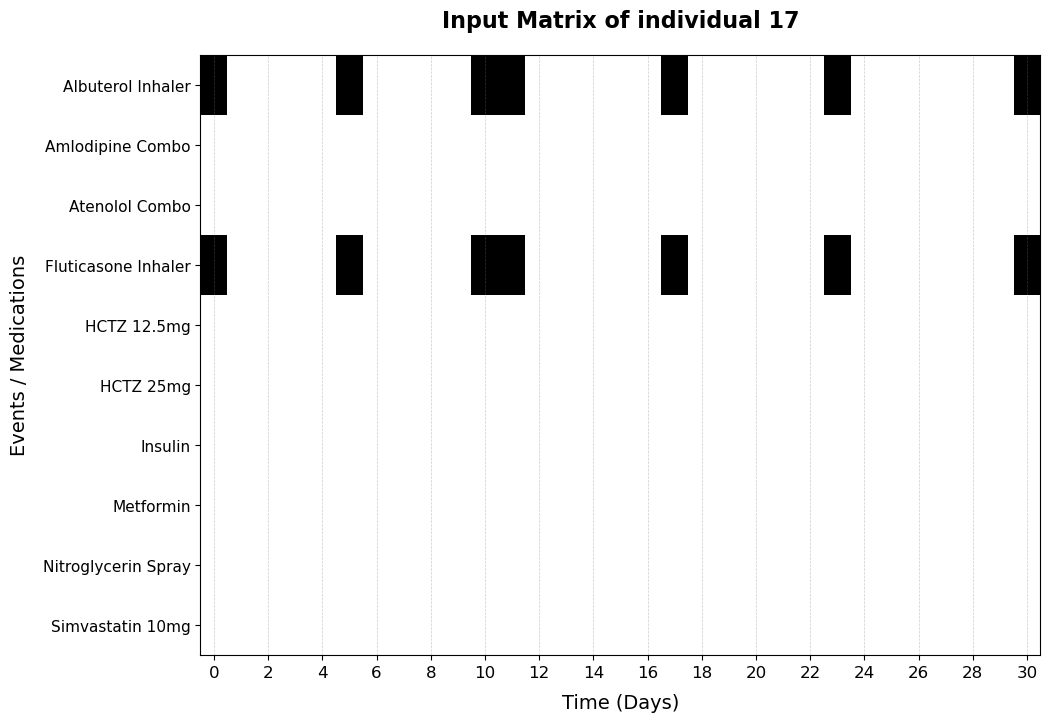

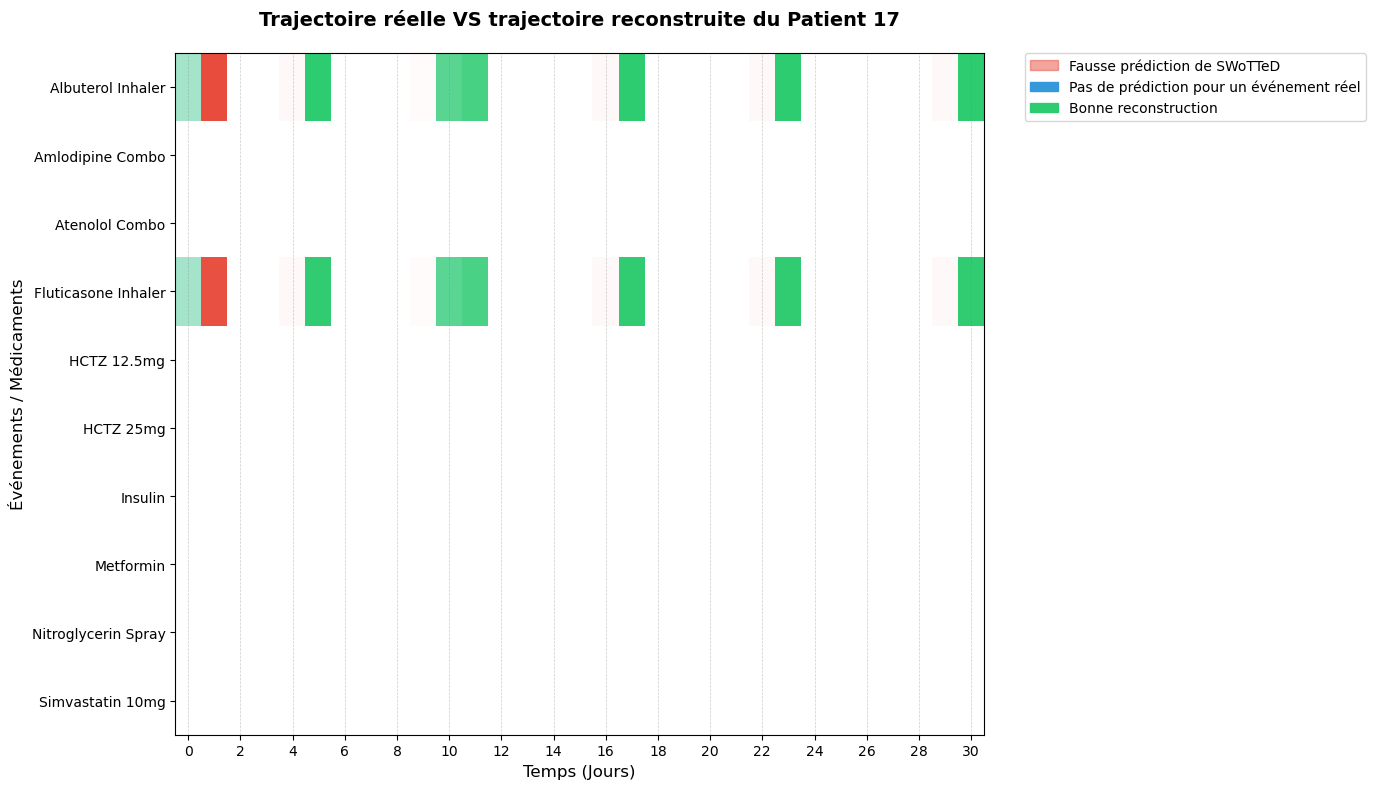

In [106]:
plot_reconstructed_vs_original(tca, patient_id=17, noms_events=noms_events)